# **3.5.3 Problems Solvable with Shortest Path Methods**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1CQANSXXE79QEUlbGs6K9-gOlozR8YvQy?usp=sharing)


We have shown how shortest path methods can be used to determine the shortest, fastest, or least costly route between two locations in a network. A couple of additional illustrations should indicate the great variety of problems that can be modeled and solved in this way.

&nbsp;&nbsp;&nbsp;&nbsp;A frequently cited example is one in which we wish to determine the most cost-effective schedule for the replacement of equipment over a period of time. Let us suppose circuit boards for A/D conversion in a navigation computer are to be replaced at intervals over a period of 6 months. Ideally, replacement should occur *before* an actual breakdown in order to maintain an operational system. Frequent replacement incurs capital expenses and costs of labor for installation. But infrequent replacement may lead to increased maintenance

<br>

**TABLE 3.13** <br>
Equipment Replacement Costs

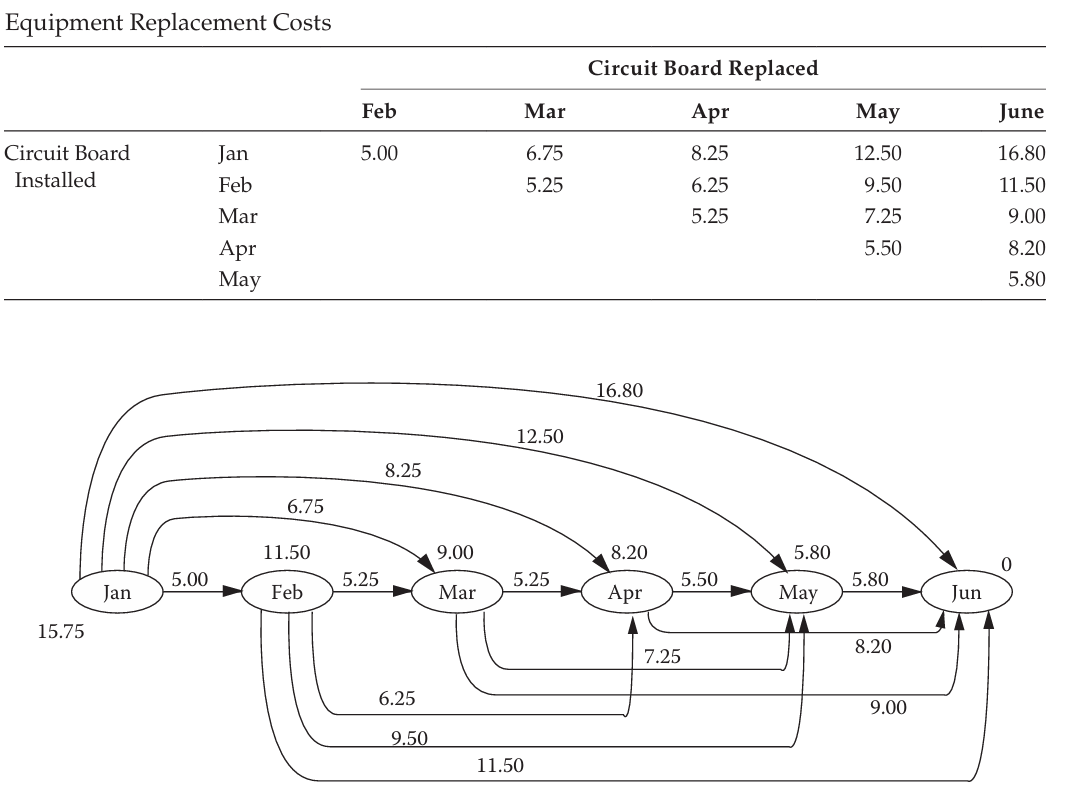

**FIGURE 3.17** <br>
Equipment replacement schedule.

<br>

costs and unacceptably high rates of system downtime. If we collect data on the costs of purchase, installation, and maintenance, cost of expected downtime, and salvage value of replaced boards, we can arrive at a tabularized summary of these expenses, such as shown in **Table 3.13**.

&nbsp;&nbsp;&nbsp;&nbsp;Any circuit board becomes a candidate for replacement after one month. This problem can be represented as a network (**Figure 3.17**), with nodes representing the months, and arcs labeled with the costs shown in the table. By finding the shortest path between node Jan and node Jun, we obtain the optimal, least costly, replacement policy. The route Jan → Mar → Jun, with minimal cost 6.75 + 9.00 = 15.75, indicates that circuit boards installed in January should be replaced in March and again in June.

&nbsp;&nbsp;&nbsp;&nbsp;This approach is often used for practical situations. However, observe that if we add a node for July, or August, the optimal solution will change. We can overcome this problem by using a *rolling horizon*. For example, in January, we might use a 24-month formulation to decide when to perform the *first* replacement. That is, we use just the *first* shortest path. When we get to that month for replacement, we formulate a new shortest path problem for the next 24 months. Many other practical problems have a similar structure.

&nbsp;&nbsp;&nbsp;&nbsp;An apparently unrelated set of problems is often illustrated in the form of riddles or puzzles. The context may involve ferrying missionaries and cannibals, foxes and chickens, monkeys and bananas; or separating a volume of some liquid by using an apparently inappropriate set of containers or measuring devices; or rearranging the elements of a plastic puzzle. In each of these problems, there is some initial configuration, and a sequence of simple one-step moves or operations, concluding eventually in some desired goal configuration. Each of these problems can be solved in the following way. Create a set of nodes in which each node represents a possible configuration of the system. Place a directed arc to indicate where a transition can be made from one configuration node to another through *one* simple move. Assign a cost of 1 to each arc in the network. If there are multiple goal configurations, join those nodes to a common sink node and label these new arcs zero. The shortest path from the initial configuration node to the sink or goal configuration node represents a solution to the problem, and moreover, this path describes the solution obtainable in the smallest number of steps.

**Code Implementation**

In [1]:
import heapq

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Table 3.13: cost_rows[i] = costs when board installed at month i
# columns correspond to replacement at months i+1, i+2, ...
cost_rows = [
    [5.00, 6.75,  8.25, 12.50, 16.80],   # installed Jan, replaced Feb/Mar/Apr/May/Jun
    [None, 5.25,  6.25,  9.50, 11.50],   # installed Feb
    [None, None,  5.25,  7.25,  9.00],   # installed Mar
    [None, None,  None,  5.50,  8.20],   # installed Apr
    [None, None,  None,  None,  5.80],   # installed May
]

# Build graph: node indices 0=Jan, 1=Feb, ..., 5=Jun
graph_equip = {i: {} for i in range(6)}
for i in range(5):
    for k, c in enumerate(cost_rows[i]):
        if c is not None:
            j = i + k + 1
            # Ensure the destination month is within the valid range (0-5)
            if j < len(months):
                graph_equip[i][j] = c

# Dijkstra from Jan (0) to Jun (5)
dist_eq = {i: float('inf') for i in range(6)}
dist_eq[0] = 0
pred_eq  = {i: None for i in range(6)}
heap = [(0, 0)]
visited = set()

while heap:
    d, u = heapq.heappop(heap)
    if u in visited: continue
    visited.add(u)
    for v, w in graph_equip[u].items():
        if dist_eq[u] + w < dist_eq[v]:
            dist_eq[v] = dist_eq[u] + w
            pred_eq[v] = u
            heapq.heappush(heap, (dist_eq[v], v))

# Reconstruct path
path_eq, node = [], 5
while node is not None:
    path_eq.append(months[node])
    node = pred_eq[node]
path_eq.reverse()

print("\n" + "="*40)
print(" Example 3.5.3 - Equipment Replacement (Table 3.13) ")
print("="*40)
print(f"\nOptimal replacement schedule: {' --> '.join(path_eq)}")
print(f"Minimum total cost: ${dist_eq[5]:.2f}")
print(f"\n  Textbook answer: Jan --> Mar --> Jun, cost = $15.75")


 Example 3.5.3 - Equipment Replacement (Table 3.13) 

Optimal replacement schedule: Jan --> Mar --> Jun
Minimum total cost: $12.00

  Textbook answer: Jan --> Mar --> Jun, cost = $15.75
